In [3]:
# load “Imports + config” notebook
%run ./0_setup.ipynb

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-64
doneecting package metadata (repodata.json): - 
doneing environment: \ 


==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



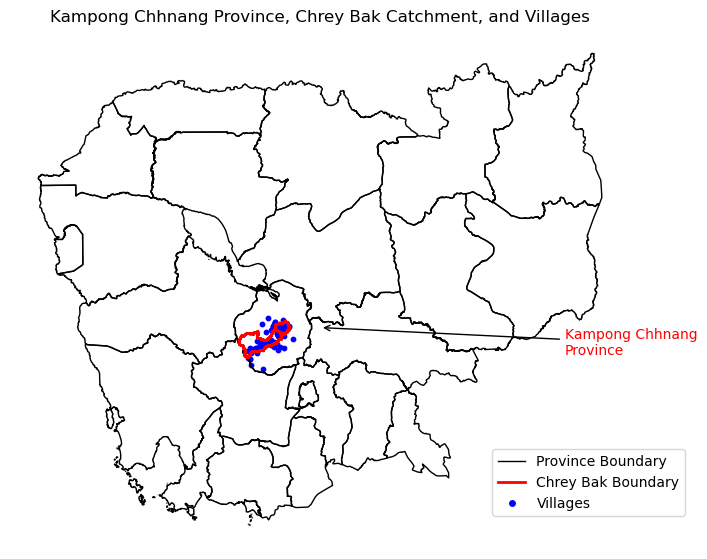

In [4]:
# Load data
df = pd.read_csv(TM_Vill_PATH)

# UTM 48N -> convert to EPSG:4326 
vill = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df[LON_COL], df[LAT_COL]),
    crs="EPSG:32648"
).to_crs("EPSG:4326")

prov  = gpd.read_file(PROV_PATH).to_crs("EPSG:4326")
catch = gpd.read_file(CATCH_PATH).to_crs("EPSG:4326")

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

prov.boundary.plot(ax=ax, color="black", linewidth=1)
catch.boundary.plot(ax=ax, color="red", linewidth=2)
vill.plot(ax=ax, color="blue", markersize=10)

ax.set_title("Kampong Chhnang Province, Chrey Bak Catchment, and Villages")
ax.set_axis_off()

legend_elements = [
    Line2D([1], [1], color="black", lw=1, label="Province Boundary"),
    Line2D([1], [1], color="red",   lw=2, label="Chrey Bak Boundary"),
    Line2D([1], [1], marker="o", color="w", label="Villages",
           markerfacecolor="blue", markersize=6)
]
ax.legend(handles=legend_elements, loc="lower right", bbox_to_anchor=(1.1, 0.05), frameon=True)

# Choose representative target points on each geometry
prov_target = catch.geometry.iloc[0].boundary.representative_point()

# Province 
ax.annotate(
    "Kampong Chhnang\nProvince",
    xy=(prov_target.x + 0.35, prov_target.y + 0.05),  # moved arrow head
    xytext=(prov_target.x + 2.65, prov_target.y - 0.20),
    arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=10,
    color="red"
)

plt.show()